# Air Passengers — Cell 1–style AR(1) vs seasonal SARIMA

**Why the naive AR(1) forecast often looks terrible here**

- The classic airline series has a **strong upward trend** and **large monthly seasonality** (period 12).
- A **single lag on levels**, \(y_t = c + \phi y_{t-1}\), cannot reproduce seasonal peaks/troughs; \(\hat\phi\approx 1\) makes the rollout **almost a random walk**, which smooths out the cycles you see in the data.
- So the red dashed line in **Figure 1** is kept only as the **same coding pattern** as `ARIMA.ipynb` Cell 1 — not as a serious model for this dataset.

**Figure 2** fits **seasonal ARIMA** on the **same train split** (before 1958-01) and forecasts the holdout **1958–1960**, using `statsmodels` — the usual approach for monthly seasonal data.

---

**Setup (both figures):** train = months before `1958-01-01`; test horizon `h = 36` months.

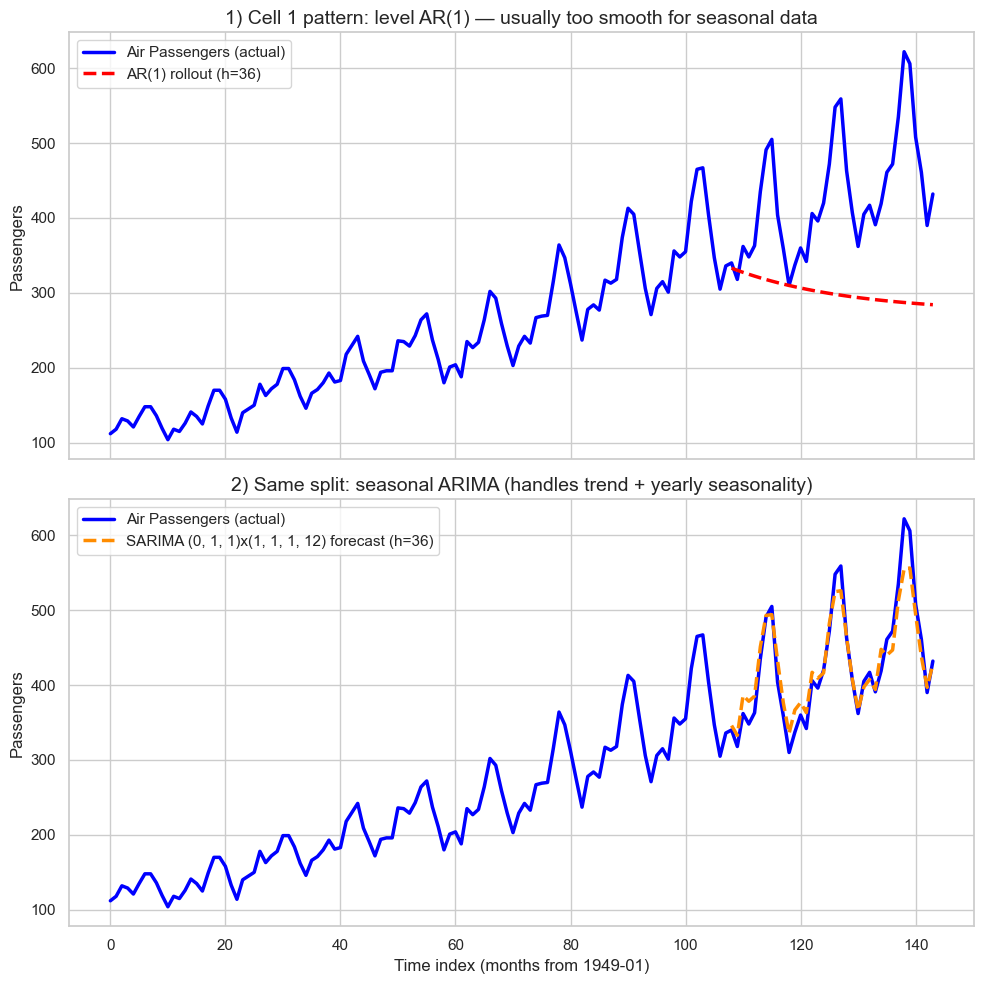

OLS AR(1): c=13.1181, phi=0.9520
Test RMSE — naive AR(1): 153.12
Test RMSE — SARIMA:      22.56


In [3]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

warnings.filterwarnings("ignore", category=FutureWarning)

_air = sm.datasets.get_rdataset("AirPassengers", "datasets").data
_idx = pd.date_range("1949-01-01", periods=len(_air), freq="MS")
y = pd.Series(_air["value"].astype(float).values, index=_idx)
_freq = pd.infer_freq(y.index)
if _freq is not None:
    y = y.copy()
    y.index = pd.DatetimeIndex(y.index, freq=_freq)

SPLIT = pd.Timestamp("1958-01-01")
y_train_arr = y.loc[y.index < SPLIT].astype(float).values.ravel()
y_train_ser = y.loc[y.index < SPLIT]
y_test_ser = y.loc[y.index >= SPLIT]
y_obs = y.astype(float).values.ravel()

n_steps = len(y_train_arr)
forecast_steps = len(y_obs) - n_steps

# --- Figure 1: exact Cell 1 recipe (OLS AR(1) + recurrence) — expect poor fit ---
X = np.column_stack([np.ones(n_steps - 1), y_train_arr[:-1]])
beta, *_ = np.linalg.lstsq(X, y_train_arr[1:], rcond=None)
c, phi = float(beta[0]), float(beta[1])

forecast_ar1 = np.zeros(n_steps + forecast_steps)
forecast_ar1[:n_steps] = y_train_arr
for t in range(n_steps, n_steps + forecast_steps):
    forecast_ar1[t] = c + phi * forecast_ar1[t - 1]

sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

axes[0].plot(y_obs, label="Air Passengers (actual)", linewidth=2.5, color="blue")
axes[0].plot(
    range(n_steps, n_steps + forecast_steps),
    forecast_ar1[n_steps:],
    linestyle="--",
    label=f"AR(1) rollout (h={forecast_steps})",
    linewidth=2.5,
    color="red",
)
axes[0].set_title(
    "1) Cell 1 pattern: level AR(1) — usually too smooth for seasonal data",
    fontsize=14,
)
axes[0].set_ylabel("Passengers")
axes[0].legend(fontsize=11)

# --- Figure 2: seasonal SARIMA on same train, forecast test ---
from statsmodels.tsa.arima.model import ARIMA

ORDER = (0, 1, 1)
SEASONAL_ORDER = (1, 1, 1, 12)
res = ARIMA(
    y_train_ser, order=ORDER, seasonal_order=SEASONAL_ORDER
).fit()
fc_sarima = res.forecast(steps=forecast_steps)
fc_vals = np.asarray(fc_sarima).ravel()

axes[1].plot(y_obs, label="Air Passengers (actual)", linewidth=2.5, color="blue")
axes[1].plot(
    range(n_steps, n_steps + forecast_steps),
    fc_vals,
    linestyle="--",
    label=f"SARIMA {ORDER}x{SEASONAL_ORDER} forecast (h={forecast_steps})",
    linewidth=2.5,
    color="darkorange",
)
axes[1].set_title(
    "2) Same split: seasonal ARIMA (handles trend + yearly seasonality)",
    fontsize=14,
)
axes[1].set_xlabel("Time index (months from 1949-01)")
axes[1].set_ylabel("Passengers")
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

# Out-of-sample RMSE on 1958–1960
y_test_vals = y_test_ser.values.astype(float)
rmse_ar1 = float(np.sqrt(np.mean((forecast_ar1[n_steps:] - y_test_vals) ** 2)))
rmse_sa = float(np.sqrt(np.mean((fc_vals - y_test_vals) ** 2)))
print(f"OLS AR(1): c={c:.4f}, phi={phi:.4f}")
print(f"Test RMSE — naive AR(1): {rmse_ar1:.2f}")
print(f"Test RMSE — SARIMA:      {rmse_sa:.2f}")
